In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# Load files
results = pd.read_csv("results.csv")
races = pd.read_csv("races.csv")
drivers = pd.read_csv("drivers.csv")
constructors = pd.read_csv("constructors.csv")

In [69]:
# Keep only needed columns
results = results[[
    "raceId", "driverId", "constructorId", "grid", "positionOrder"
]]

# Convert to numeric
results["grid"] = pd.to_numeric(results["grid"], errors="coerce")
results["positionOrder"] = pd.to_numeric(results["positionOrder"], errors="coerce")

# Remove bad rows
results = results.dropna(subset=["grid", "positionOrder"])

In [70]:
df = results.merge(races, on="raceId", how="left")
df = df.merge(drivers, on="driverId", how="left")
df = df.merge(constructors, on="constructorId", how="left")

df = df[[
    "raceId",
    "driverId",
    "constructorId",
    "grid",
    "positionOrder",
    "circuitId"
]].copy()

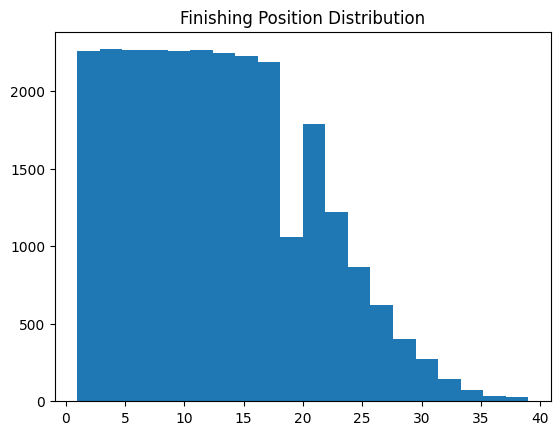

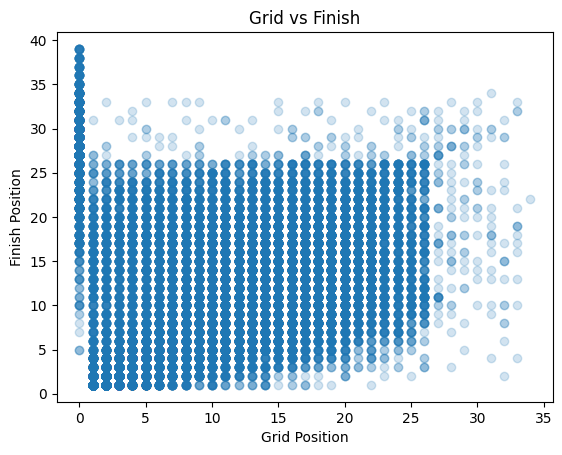

In [71]:
# Distribution
plt.hist(df["positionOrder"], bins=20)
plt.title("Finishing Position Distribution")
plt.show()

# Grid vs Finish
plt.scatter(df["grid"], df["positionOrder"], alpha=0.2)
plt.xlabel("Grid Position")
plt.ylabel("Finish Position")
plt.title("Grid vs Finish")
plt.show()

In [72]:
# Remove unrealistic values
df = df[(df["grid"] > 0) & (df["grid"] <= 20)]
df = df[df["positionOrder"] <= 20]

df = df.reset_index(drop=True)

In [73]:
df = df.sort_values(by=["driverId", "raceId"])

# Driver form
df["driver_form"] = (
    df.groupby("driverId")["positionOrder"]
      .rolling(5, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

# Constructor form
df["constructor_form"] = (
    df.groupby("constructorId")["positionOrder"]
      .rolling(5, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
)

# Experience
df["experience"] = df.groupby("driverId").cumcount()

# Remove NaNs from rolling
df = df.dropna(subset=["driver_form", "constructor_form"])

In [74]:
df = df.sort_values("raceId")

split = int(len(df) * 0.8)

train_df = df.iloc[:split]
test_df  = df.iloc[split:]

In [75]:
features = [
    "grid",
    "driver_form",
    "constructor_form",
    "experience"
]

X_train = train_df[features]
X_test  = test_df[features]

y_train = train_df["positionOrder"]
y_test  = test_df["positionOrder"]

In [76]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 2.9349982738494873
R2 Score: 0.540965735912323
